In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
def load_and_impute():
    california = fetch_california_housing(as_frame=True)
    df = california.data
    df['MedHouseVal'] = california.target

    target_col='MedHouseVal'
    feature_names = california.feature_names
    data = df.copy()
    
    median_target = data[target_col].median()
    y = (data[target_col] > median_target).astype(int).values
    X = data.drop(columns=[target_col]).values

    col_means = np.nanmean(X, axis=0)
    inds = np.where(np.isnan(X))
    X[inds] = np.take(col_means, inds[1])
    
    return X, y, feature_names

In [3]:
class standardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        return self

    def transform(self, X):
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [4]:
def train_test_split_scaled(X, y, train_ratio=0.8, val_ratio=0.1, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)

    split_idx1 = int(train_ratio * n_samples)
    split_idx2 = int((train_ratio+val_ratio) * n_samples)

    train_idx = indices[:split_idx1]
    val_idx = indices[split_idx1:split_idx2]
    test_idx = indices[split_idx2:]

    scaler = standardScaler()
    X_train = scaler.fit_transform(X[train_idx])
    X_val = scaler.transform(X[val_idx])
    X_test = scaler.transform( X[test_idx])

    return X_train, y[train_idx], X_val, y[val_idx], X_test, y[test_idx]

In [5]:
X, y, feature_names = load_and_impute()
X_train, y_train, X_val, y_val, X_test, y_test = train_test_split_scaled(X, y, train_ratio=0.8, val_ratio=0.1)

In [6]:
class SVMManager:
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.best_model = None
        self.best_params = None

    def find_best_params(self, X_train, y_train):
        print("Starting Grid Search for SVM...")
        
        param_grid = {
            'C': [0.1, 1, 10],
            'gamma': ['auto', 0.01, 0.1, 1, 10],
            'kernel': ['rbf']
        }
        
        svc = SVC(probability=True, random_state=self.random_state)
        
        grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, 
                                   cv=3, scoring='f1', n_jobs=-1, verbose=1)
        
        grid_search.fit(X_train, y_train)
        
        self.best_params = grid_search.best_params_
        self.best_model = grid_search.best_estimator_
        
        print(f"Best Params found: {self.best_params}")
        return self.best_model

    def evaluate(self, X_test, y_test):
        if self.best_model is None:
            raise Exception("Model not trained yet!")
            
        y_pred = self.best_model.predict(X_test)
        y_prob = self.best_model.predict_proba(X_test)[:, 1]
        
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        
        return f1, auc

In [7]:
svm_manager = SVMManager(random_state=42)
svm_manager.find_best_params(X_train, y_train)
f1, auc = svm_manager.evaluate(X_test, y_test)
print(f"SVM Test Results -> F1: {f1:.4f}, AUC: {auc:.4f}")

Starting Grid Search for SVM...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Params found: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
SVM Test Results -> F1: 0.8640, AUC: 0.9439


In [8]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [9]:
class HousingMLP(nn.Module):
    def __init__(self, input_dim):
        super(HousingMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        logits = self.net(x)
        return logits

In [10]:
def train_mlp_model(X_train, y_train, X_val, y_val, lr=0.01, max_epochs=100, batch_size=64, seed=42):
    set_seed(seed)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    input_dim = X_train.shape[1]
    model = HousingMLP(input_dim)
    
    criterion = nn.BCEWithLogitsLoss() 
    optimizer = optim.SGD(model.parameters(), lr=lr)

    prev_val_loss = float('inf')
    loss_increase_counter = 0
    best_model_state = None
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss = criterion(val_logits, y_val_t).item()
            
            probs = torch.sigmoid(val_logits)
            preds = (probs > 0.5).float()
            acc = (preds == y_val_t).float().mean().item()

        history['train_loss'].append(epoch_loss / len(train_loader))
        history['val_loss'].append(val_loss)
        history['val_acc'].append(acc)

        if val_loss > prev_val_loss:
            loss_increase_counter += 1
        else:
            loss_increase_counter = 0
            best_model_state = model.state_dict()

        if loss_increase_counter >= 3:
            print(f"Early stopping at epoch {epoch+1}")
            if best_model_state:
                model.load_state_dict(best_model_state)
            break

        prev_val_loss = val_loss

    return model, history

In [11]:
def evaluate_mlp(model, X_test, y_test):
    model.eval()
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.sigmoid(logits).numpy().flatten()
        preds = (probs > 0.5).astype(int)
    
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    return f1, auc, preds

In [12]:
from sklearn.base import BaseEstimator, ClassifierMixin

class PyTorchMLPWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim, model_state=None):
        self.input_dim = input_dim
        self.model = HousingMLP(input_dim)
        if model_state:
            self.model.load_state_dict(model_state)
        self.model.eval()

    def fit(self, X, y):
        return self

    def predict(self, X):
        X_t = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            logits = self.model(X_t)
            probs = torch.sigmoid(logits).numpy().flatten()
            preds = (probs > 0.5).astype(int)
        return preds

    def score(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)


In [13]:
from sklearn.inspection import permutation_importance

class FeatureAnalyzer:
    def __init__(self, feature_names):
        self.feature_names = np.array(feature_names)
        self.ranked_features_indices = None
        self.importances_mean = None

    def compute_and_plot_importance(self, model_wrapper, X_val, y_val, model_name="Model"):
        print(f"Computing Permutation Importance for {model_name}...")
        results = permutation_importance(model_wrapper, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
        
        self.importances_mean = results.importances_mean
        sorted_idx = results.importances_mean.argsort()
        self.ranked_features_indices = sorted_idx
        
        plt.figure(figsize=(10, 6))
        plt.barh(self.feature_names[sorted_idx], results.importances_mean[sorted_idx])
        plt.title(f"{model_name} Feature Importance")
        plt.tight_layout()
        plt.show()
        return self.feature_names[sorted_idx]

    # --------------------------------------------------------

    def run_sequential_ablation(self, model_type, X_train, y_train, X_test, y_test):
        if self.ranked_features_indices is None:
            raise Exception("Please run compute_importance first!")

        sorted_indices = self.ranked_features_indices
        n_features = len(sorted_indices)
        results = {'num_features': [], 'accuracy': []}
        
        features_to_drop_counts = range(0, n_features - 1)
        
        print(f"\nStarting Sequential Ablation for {model_type}...")
        for i in features_to_drop_counts:
            if i == 0: keep_indices = sorted_indices
            else: keep_indices = sorted_indices[i:]
            
            if len(keep_indices) < 2: break
                
            X_tr_sub = X_train[:, keep_indices]
            X_te_sub = X_test[:, keep_indices]
            
            acc = self._train_and_evaluate(model_type, X_tr_sub, y_train, X_te_sub, y_test)
            results['num_features'].append(len(keep_indices))
            results['accuracy'].append(acc)
            
        return results

    def run_random_experiment(self, model_type, X_train, y_train, X_test, y_test, removal_counts=[1, 4, 6], n_repeats=10):
        n_total_features = X_train.shape[1]
        stats = {'counts': removal_counts, 'means': [], 'stds': []}
        
        print(f"\nStarting Random Experiment for {model_type} (Repeats={n_repeats})...")
        
        for count in removal_counts:
            n_keep = n_total_features - count
            accuracies = []
            
            for i in range(n_repeats):
                keep_indices = np.random.choice(n_total_features, n_keep, replace=False)
                
                X_tr_sub = X_train[:, keep_indices]
                X_te_sub = X_test[:, keep_indices]
                
                acc = self._train_and_evaluate(model_type, X_tr_sub, y_train, X_te_sub, y_test, seed=i)
                accuracies.append(acc)
            
            mean_acc = np.mean(accuracies)
            std_acc = np.std(accuracies)
            stats['means'].append(mean_acc)
            stats['stds'].append(std_acc)
            
            print(f"Removed {count}: Mean={mean_acc:.4f}, Std={std_acc:.4f}")
            
        return stats


    def _train_and_evaluate(self, model_type, X_tr, y_tr, X_te, y_te, seed=42):
        if model_type == 'svm':
            svm = SVC(C=1, gamma='auto', kernel='rbf', random_state=seed)
            svm.fit(X_tr, y_tr)
            return svm.score(X_te, y_te)
            
        elif model_type == 'mlp':
            model, _ = train_mlp_model(
                X_tr, y_tr, X_te, y_te, 
                max_epochs=30, batch_size=64, seed=seed
            )
            _, _, preds = evaluate_mlp(model, X_te, y_te)
            return np.mean(preds == y_te)


--- SVM Analysis ---
Computing Permutation Importance for SVM...


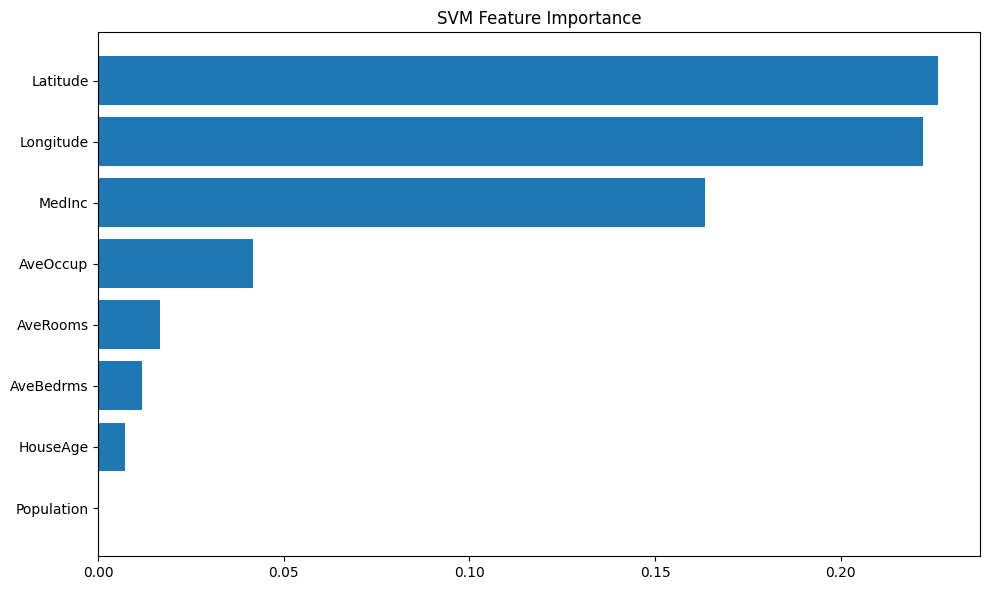


Starting Sequential Ablation for svm...

Starting Random Experiment for svm (Repeats=10)...
Removed 1: Mean=0.8409, Std=0.0118
Removed 4: Mean=0.7462, Std=0.0448
Removed 6: Mean=0.6653, Std=0.0504


In [15]:
print("--- SVM Analysis ---")

svm_analyzer = FeatureAnalyzer(feature_names)

svm_analyzer.compute_and_plot_importance(
    svm_manager.best_model, 
    X_val, y_val, 
    model_name="SVM"
)

svm_sorted_res = svm_analyzer.run_sequential_ablation('svm', X_train, y_train, X_test, y_test)
svm_random_res = svm_analyzer.run_random_experiment(
    'svm', X_train, y_train, X_test, y_test,
    removal_counts=[1, 4, 6], n_repeats=10
)


--- MLP Analysis ---
Computing Permutation Importance for MLP...


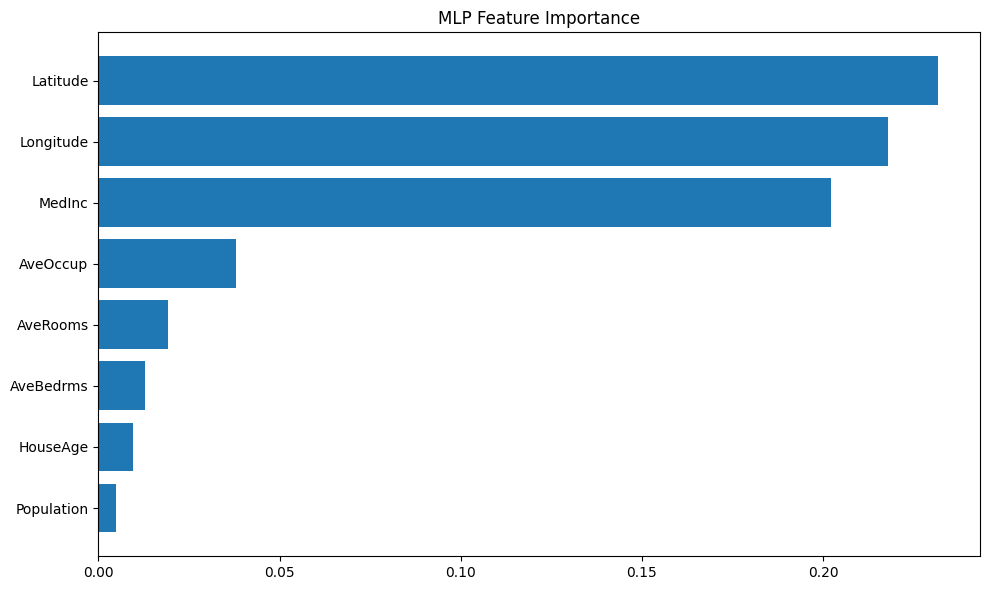


Starting Sequential Ablation for mlp...
Early stopping at epoch 17

Starting Random Experiment for mlp (Repeats=10)...
Early stopping at epoch 18
Removed 1: Mean=0.8291, Std=0.0108
Removed 4: Mean=0.7583, Std=0.0645
Early stopping at epoch 7
Removed 6: Mean=0.6778, Std=0.0604


In [16]:
print("\n--- MLP Analysis ---")
mlp_model, _ = train_mlp_model(
    X_train, y_train, 
    X_val, y_val, 
    lr=0.01
)

mlp_wrapper = PyTorchMLPWrapper(input_dim=8, model_state=mlp_model.state_dict())

mlp_analyzer = FeatureAnalyzer(feature_names)

mlp_analyzer.compute_and_plot_importance(
    mlp_wrapper, 
    X_val, y_val,
    model_name="MLP"
)

mlp_sorted_res = mlp_analyzer.run_sequential_ablation('mlp', X_train, y_train, X_test, y_test)
mlp_random_res = mlp_analyzer.run_random_experiment(
    'mlp', X_train, y_train, X_test, y_test,
    removal_counts=[1, 4, 6], n_repeats=10
)

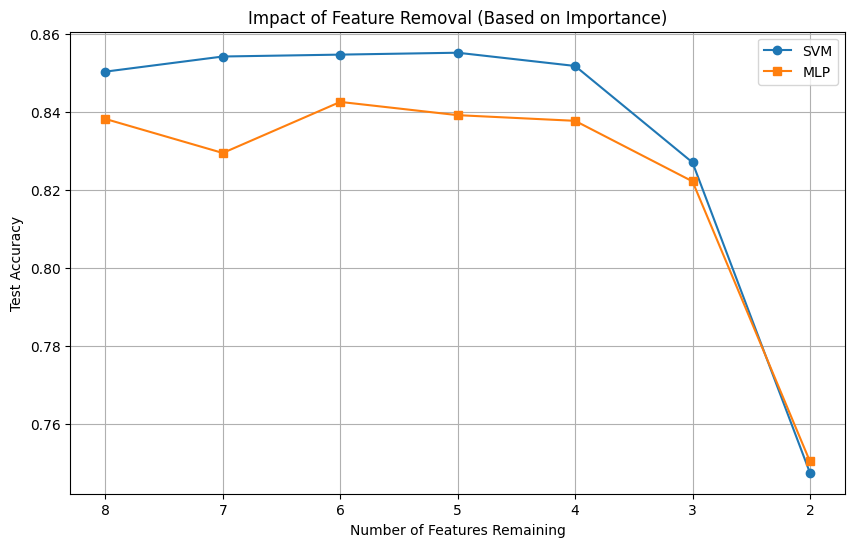

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(svm_sorted_res['num_features'], svm_sorted_res['accuracy'], marker='o', label='SVM')
plt.plot(mlp_sorted_res['num_features'], mlp_sorted_res['accuracy'], marker='s', label='MLP')
plt.gca().invert_xaxis()
plt.xlabel("Number of Features Remaining")
plt.ylabel("Test Accuracy")
plt.title("Impact of Feature Removal (Based on Importance)")
plt.legend()
plt.grid(True)
plt.show()

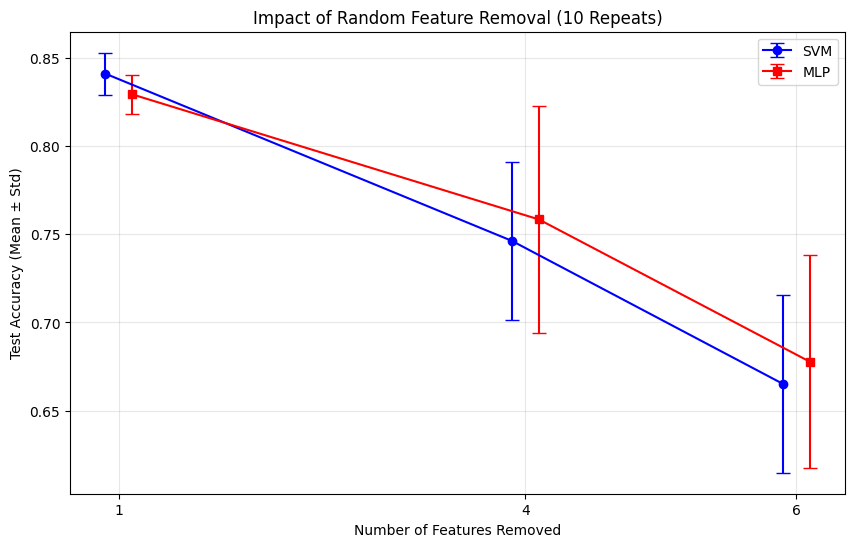

In [18]:
plt.figure(figsize=(10, 6))
x_pos = np.array(svm_random_res['counts'])
plt.errorbar(x_pos - 0.1, svm_random_res['means'], yerr=svm_random_res['stds'], 
             fmt='-o', capsize=5, label='SVM', color='blue')

plt.errorbar(x_pos + 0.1, mlp_random_res['means'], yerr=mlp_random_res['stds'], 
             fmt='-s', capsize=5, label='MLP', color='red')

plt.xlabel("Number of Features Removed")
plt.ylabel("Test Accuracy (Mean ± Std)")
plt.title("Impact of Random Feature Removal (10 Repeats)")
plt.xticks(x_pos)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()